# Project 05 – Clinical Trial Disease Category Classification
## Step 01: Data Cleaning, Basic EDA, Text Preprocessing, TF-IDF and Logistic Regression

**Dataset:** `clinical_trial_disease_dataset.csv`  
**Text Feature:** `brief_summary`  
**Target:** `source_condition_query`

The remaining clinical-trial columns are retained as supporting metadata and are included in basic cleaning and EDA, but they are not model features.

In [1]:
import os
import string
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

os.makedirs("model_files", exist_ok=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

## 1. Load Dataset

In [2]:
df = pd.read_csv("clinical_trial_disease_dataset.csv")
print("Dataset Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Dataset Shape: (60337, 16)
Columns: ['source_condition_query', 'nct_id', 'title', 'official_title', 'brief_summary', 'conditions', 'interventions', 'overall_status', 'study_type', 'phase', 'sex', 'minimum_age', 'maximum_age', 'healthy_volunteers', 'eligibility_criteria', 'clinicaltrials_url']


,source_condition_query,nct_id,title,official_title,brief_summary,conditions,interventions,overall_status,study_type,phase,sex,minimum_age,maximum_age,healthy_volunteers,eligibility_criteria,clinicaltrials_url
0,breast cancer,NCT03676114,Effect of Perioperative Low Dose Ketamine on P...,Effect of Perioperative Low Dose Ketamine on P...,Breast cancer patients often have perioperativ...,Breast Cancer,ketamine | Normal saline,UNKNOWN,INTERVENTIONAL,PHASE4,FEMALE,20 Years,65 Years,False,Inclusion Criteria:\n\n1. American Society of ...,https://clinicaltrials.gov/study/NCT03676114
1,breast cancer,NCT02941614,Implementing Systematic Distress Screening in ...,Implementing Systematic Distress Screening in ...,Many breast cancer patients experience psychol...,Breast Cancer,Distress screening,COMPLETED,OBSERVATIONAL,NaN,ALL,18 Years,NaN,False,Inclusion Criteria:\n\n* Newly diagnosed with ...,https://clinicaltrials.gov/study/NCT02941614
2,breast cancer,NCT04509063,Investigating Public Enthusiasm for Mammograph...,Investigating Public Enthusiasm for Mammograph...,"Based on an American study by Scherer et al., ...",Breast Neoplasm Female | Mammography Screening...,Information about hypothetical mammography scr...,COMPLETED,INTERVENTIONAL,NaN,FEMALE,44 Years,49 Years,True,Inclusion Criteria:\n\n* Residence: Central De...,https://clinicaltrials.gov/study/NCT04509063
3,breast cancer,NCT04327063,MIRs 04 : Interpectoral Nerve Block With Ropiv...,A Double-blind Randomized Trial of Interpector...,Compare the effect of ropivacaine versus place...,Malignant Neoplasm of Breast,Saline | Ropivacaine,COMPLETED,INTERVENTIONAL,PHASE3,FEMALE,18 Years,85 Years,False,Inclusion Criteria:\n\n1. Women with non-metas...,https://clinicaltrials.gov/study/NCT04327063
4,breast cancer,NCT06778863,A Study of CLSP-1025 in Adult Patients With So...,GUARDIAN-101: A Phase 1 Dose Escalation and Ex...,Phase 1 dose escalation and expansion study of...,Advanced Solid Tumor | Unresectable Solid Tumo...,CLSP-1025,RECRUITING,INTERVENTIONAL,PHASE1,ALL,18 Years,NaN,False,Key Inclusion Criteria:\n\n* Patients must be ...,https://clinicaltrials.gov/study/NCT06778863


## 2. Dataset Overview & Basic Cleaning

In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))
print("Duplicate Rows:", df.duplicated().sum())
if "nct_id" in df.columns:
    print("Duplicate NCT IDs:", df["nct_id"].duplicated().sum())

Rows: 60337
Columns: 16

Data Types:


,Data Type
source_condition_query,object
nct_id,object
title,object
official_title,object
brief_summary,object
conditions,object
interventions,object
overall_status,object
study_type,object
phase,object


Duplicate Rows: 0
Duplicate NCT IDs: 0


In [4]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Count", ascending=False)
display(missing_summary)

text_col = "brief_summary"
target_col = "source_condition_query"

df[text_col] = df[text_col].fillna("")
df[target_col] = df[target_col].fillna("Unknown")

supporting_cols = [
    "nct_id","title","official_title","conditions","interventions",
    "overall_status","study_type","phase","sex","minimum_age",
    "maximum_age","healthy_volunteers","eligibility_criteria",
    "clinicaltrials_url"
]
for col in supporting_cols:
    if col in df.columns and df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")

print("Basic missing-value cleaning completed.")

,Missing Count,Missing %
phase,37001,61.32
maximum_age,31937,52.93
interventions,6061,10.05
minimum_age,3216,5.33
healthy_volunteers,1480,2.45
official_title,786,1.30
sex,33,0.05
eligibility_criteria,11,0.02
conditions,1,0.00
overall_status,0,0.00


Basic missing-value cleaning completed.


## 3. Basic EDA – Clinical Trial Metadata

The supporting columns are explored for dataset understanding. They are not passed into the NLP classification model.

,Count
source_condition_query,
breast cancer,16301
type 2 diabetes,11467
covid-19,10153
anxiety,9286
chronic obstructive pulmonary disease,6181
rheumatoid arthritis,3637
glaucoma,2173
sickle cell anemia,1139


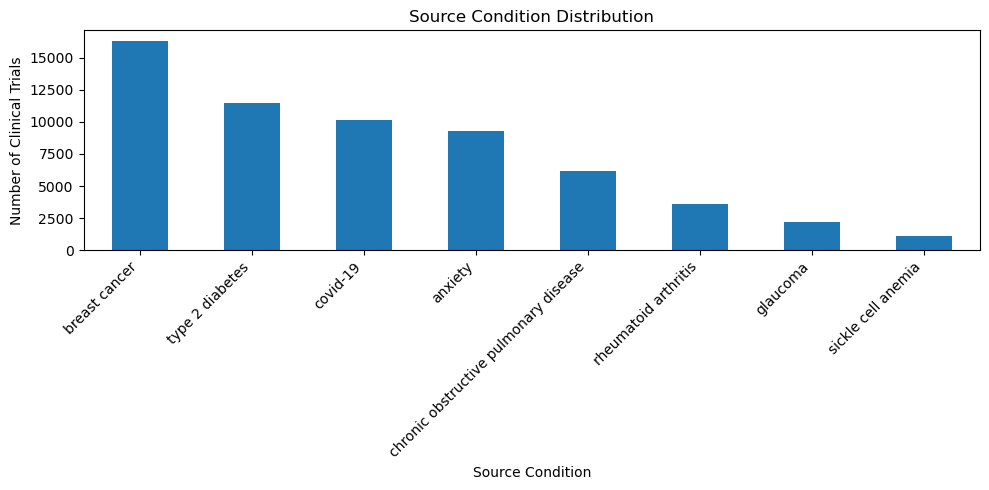

In [5]:
target_counts = df[target_col].value_counts()
display(target_counts.to_frame("Count"))

plt.figure(figsize=(10,5))
target_counts.plot(kind="bar")
plt.title("Source Condition Distribution")
plt.xlabel("Source Condition")
plt.ylabel("Number of Clinical Trials")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [6]:
for col in ["overall_status","study_type","phase","sex","healthy_volunteers"]:
    if col in df.columns:
        print(f"--- {col} ---")
        display(df[col].value_counts().head(15).to_frame("Count"))

--- overall_status ---


,Count
overall_status,
COMPLETED,33659
UNKNOWN,9454
RECRUITING,6089
TERMINATED,3761
ACTIVE_NOT_RECRUITING,2468
NOT_YET_RECRUITING,2402
WITHDRAWN,1750
ENROLLING_BY_INVITATION,461
SUSPENDED,203


--- study_type ---


,Count
study_type,
INTERVENTIONAL,45548
OBSERVATIONAL,14699
EXPANDED_ACCESS,90


--- phase ---


,Count
phase,
Unknown,37001
PHASE2,7408
PHASE3,5201
PHASE1,4160
PHASE4,3495
PHASE1 | PHASE2,1708
PHASE2 | PHASE3,821
EARLY_PHASE1,543


--- sex ---


,Count
sex,
ALL,47436
FEMALE,11925
MALE,943
Unknown,33


--- healthy_volunteers ---


,Count
healthy_volunteers,
False,45860
True,12997
Unknown,1480


In [7]:
metadata_cols = ["title","official_title","conditions","interventions","eligibility_criteria"]
summary=[]
for col in metadata_cols:
    if col in df.columns:
        non_empty=df[col].astype(str).str.strip().ne("").sum()
        summary.append({
            "Column":col,
            "Non-Empty Rows":non_empty,
            "Empty/Unknown Rows":len(df)-non_empty
        })
display(pd.DataFrame(summary))

,Column,Non-Empty Rows,Empty/Unknown Rows
0,title,60337,0
1,official_title,60337,0
2,conditions,60337,0
3,interventions,60337,0
4,eligibility_criteria,60337,0


In [8]:
for col in ["minimum_age","maximum_age"]:
    if col in df.columns:
        print(f"--- {col} sample values ---")
        display(df[col].value_counts().head(15).to_frame("Count"))

--- minimum_age sample values ---


,Count
minimum_age,
18 Years,39226
40 Years,3423
Unknown,3216
20 Years,2003
30 Years,1283
21 Years,1274
19 Years,871
50 Years,809
35 Years,749


--- maximum_age sample values ---


,Count
maximum_age,
Unknown,31937
75 Years,4100
65 Years,3928
80 Years,3480
70 Years,3337
60 Years,1313
85 Years,1069
90 Years,916
55 Years,810


## 4. Select Input and Target

**Input/Text Feature:** `brief_summary`  
**Target:** `source_condition_query`

Other clinical-trial columns remain available as metadata.

In [9]:
print("Text Feature:", text_col)
print("Target:", target_col)
display(df[[target_col,text_col]].head())

Text Feature: brief_summary
Target: source_condition_query


,source_condition_query,brief_summary
0,breast cancer,Breast cancer patients often have perioperativ...
1,breast cancer,Many breast cancer patients experience psychol...
2,breast cancer,"Based on an American study by Scherer et al., ..."
3,breast cancer,Compare the effect of ropivacaine versus place...
4,breast cancer,Phase 1 dose escalation and expansion study of...


## 5. Text Preprocessing

Lowercase → punctuation removal → special-character cleanup → tokenization → stop-word removal → lemmatization.

In [10]:
df["brief_summary_clean"] = df[text_col].str.lower()
df["brief_summary_clean"] = df["brief_summary_clean"].apply(
    lambda x: x.translate(str.maketrans("", "", string.punctuation))
)
df["brief_summary_clean"] = (
    df["brief_summary_clean"]
    .str.replace(r"[^a-zA-Z0-9\s]", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
df["tokens"] = df["brief_summary_clean"].apply(str.split)

stop_words = set(stopwords.words("english"))
df["tokens_no_stopwords"] = df["tokens"].apply(
    lambda xs: [w for w in xs if w not in stop_words]
)
lemmatizer = WordNetLemmatizer()
df["tokens_lemmatized"] = df["tokens_no_stopwords"].apply(
    lambda xs: [lemmatizer.lemmatize(w) for w in xs]
)
df["brief_summary_preprocessed"] = df["tokens_lemmatized"].apply(" ".join)
display(df[[text_col,"brief_summary_preprocessed"]].head())

,brief_summary,brief_summary_preprocessed
0,Breast cancer patients often have perioperativ...,breast cancer patient often perioperative emot...
1,Many breast cancer patients experience psychol...,many breast cancer patient experience psycholo...
2,"Based on an American study by Scherer et al., ...",based american study scherer et al hypothesize...
3,Compare the effect of ropivacaine versus place...,compare effect ropivacaine versus placebo pect...
4,Phase 1 dose escalation and expansion study of...,phase 1 dose escalation expansion study clsp10...


## 6. Save Step 01 Processed Data

In [11]:
df.to_csv("step01_processed_data.csv", index=False)
print("Saved step01_processed_data.csv")
print("Saved shape:", df.shape)

Saved step01_processed_data.csv
Saved shape: (60337, 21)


## 7. Train-Test Split

In [12]:
X_text=df["brief_summary_preprocessed"]
y=df[target_col]
X_train_text,X_test_text,y_train,y_test=train_test_split(
    X_text,y,test_size=0.20,random_state=42,stratify=y
)
print("Training rows:",len(X_train_text))
print("Testing rows:",len(X_test_text))

Training rows: 48269
Testing rows: 12068


## 8. TF-IDF Vectorization

In [13]:
tfidf=TfidfVectorizer()
X_train_tfidf=tfidf.fit_transform(X_train_text)
X_test_tfidf=tfidf.transform(X_test_text)
print("X_train TF-IDF:",X_train_tfidf.shape)
print("X_test TF-IDF:",X_test_tfidf.shape)

X_train TF-IDF: (48269, 78911)
X_test TF-IDF: (12068, 78911)


## 9. Model 1 – Logistic Regression Baseline

In [14]:
logistic_model=LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_tfidf,y_train)
y_pred_lr=logistic_model.predict(X_test_tfidf)

metrics={
    "Accuracy":accuracy_score(y_test,y_pred_lr),
    "Precision":precision_score(y_test,y_pred_lr,average="weighted",zero_division=0),
    "Recall":recall_score(y_test,y_pred_lr,average="weighted",zero_division=0),
    "F1-Score":f1_score(y_test,y_pred_lr,average="weighted",zero_division=0)
}
for k,v in metrics.items():
    print(f"{k}: {v:.4f}")

Accuracy: 0.9453
Precision: 0.9463
Recall: 0.9453
F1-Score: 0.9452


In [15]:
print(classification_report(y_test,y_pred_lr,zero_division=0))

                                       precision    recall  f1-score   support

                              anxiety       0.90      0.96      0.93      1857
                        breast cancer       0.96      0.97      0.96      3260
chronic obstructive pulmonary disease       0.94      0.91      0.92      1236
                             covid-19       0.96      0.93      0.95      2031
                             glaucoma       0.98      0.93      0.96       435
                 rheumatoid arthritis       0.98      0.88      0.92       727
                   sickle cell anemia       0.99      0.83      0.90       228
                      type 2 diabetes       0.94      0.96      0.95      2294

                             accuracy                           0.95     12068
                            macro avg       0.96      0.92      0.94     12068
                         weighted avg       0.95      0.95      0.95     12068

